# TCCT S86D - Full Combined K Feasibility Scan

Audit-only scan over the 113 K values that passed S86C. Propagation is run once for 264 historical and 288 revealed S86 rows; every K reuses the same raw observations. No policy is applied to the frozen candidate and no candidate is exported.


Dataset[{<|Stage -> S86, Name -> ExternalSixBranchBlind, CandidateFileLoaded -> True, 
 
>     CandidateHash -> a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     ExpectedCandidateHash -> 
 
>      a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     CandidateK -> 19, CandidatePolicyLength -> 26, 
 
>     OriginalFrozenModelChanged -> False, FrozenCandidateChanged -> False, 
 
>     CoreChanged -> False, PreflightPassed -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, CandidateFileLoaded, 
 
>      CandidateHash, ExpectedCandidateHash, CandidateK, CandidatePolicyLength, 
 
>      OriginalFrozenModelChanged, FrozenCandidateChanged, CoreChanged, PreflightPassed}\
 
>      , {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
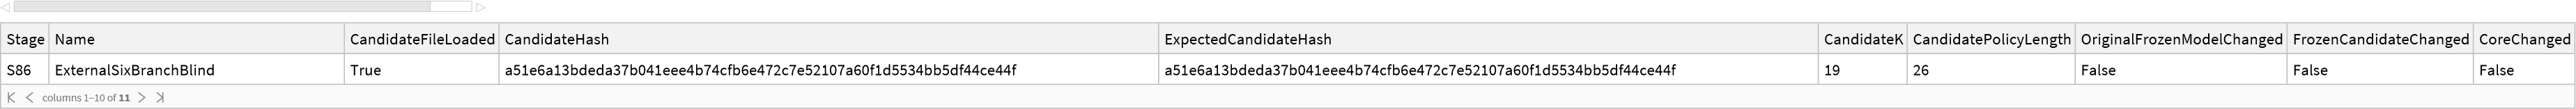

In [5]:
ClearAll["Global`*"];
$HistoryLength=0;

expectedFrozenModelHash79A=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedTopologySpecHash79A=
"b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b";
expectedTopologyImplementationHash79A=
"f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52";
expectedS79BlindResultHash79A=
"b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8661d";

frozen75D=<|
"Stage"->"S75D",
"Name"->"ValidatedPolicyCompletion",
"Representation"->
"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"TrainingPolicy"->{{3,1},{3,3},{4,3}},
"Policy"->{
{1,3},{2,2},{3,1},{3,2},{3,3},{4,3}
},
"AddedContinueCodes"->{{1,3},{2,2},{3,2}},
"PolicyCompletionUsesValidationLabels"->True,
"FrozenBeforeS76"->True
|>;

P59[a_,b_,n_Integer,s_Integer]:=If[
n<=0,
{DirectedEdge[a,b]},
DirectedEdge@@@Partition[
Join[{a},Range[s,s+n-1],{b}],
2,
1
]
];

A59[t_,fan_Integer,s_Integer]:=Module[{p1,p2,ls},
p1=s+1;
p2=s+2;
ls=Range[s+3,s+2+fan];
Join[
{
DirectedEdge[p2,p1],
DirectedEdge[p1,t]
},
Table[
DirectedEdge[ls[[i]],p2],
{i,Length[ls]}
]
]
];

T59[d_Integer,r_String,a_Integer,seed_Integer]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dum,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,4}];
v=Table[bb+200+i,{i,4}];
q=Table[bb+300+i,{i,4}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,4}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,4]]];
main=Join[
P59[q[[i]],r1,d,ib+1000000],
P59[q[[i]],r2,d,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,d+1,ib+3000000]
];
perm=If[
r==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dum]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,4}
];
{{Union[e],q,K,v,c,f},a}
];

Case59[d_Integer,a_Integer,r_String]:=
T59[d,r,a,59000000+100 d+a];

rw60={-9,6,-2,-2,4,2,-2,6,0};

Pack60[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,v,pos,gi,go,pa,ch,id,od,
pin,pout,cin,cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[v,Range[Length[v]]];
gi=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{w,u}],
First->Last
];
go=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{u,w}],
First->Last
];
pa=(Lookup[pos,Lookup[gi,#,{}]]&)/@v;
ch=(Lookup[pos,Lookup[go,#,{}]]&)/@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout=(Total[od[[#]]]&)/@pa;
cin=(Total[id[[#]]]&)/@ch;
cout=(Total[od[[#]]]&)/@ch;
{
pa,id,od,
Lookup[pos,x[[2,a]]],
Lookup[pos,x[[5]]],
a,
Length[v],
pin,pout,cin,cout,v
}
];

SigLevels61[c_List,rmax_Integer]:=Module[
{p,pa,id,od,n,ch,cur,nxt,levs,j,k,u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{},n];
Do[
Do[
If[u>0,ch[[u]]=Append[ch[[u]],j]],
{u,pa[[j]]}
],
{j,n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id,od}]
];
levs={cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur,j],
Sort[Lookup[cur,pa[[j]]]],
Sort[Lookup[cur,ch[[j]]]]
},
{j,n}
]
];
AppendTo[levs,nxt];
cur=nxt,
{k,rmax}
];
levs
];

PropagationSafetyCap78[c_List]:=Module[{n},
n=Pack60[c][[7]];
Max[64,2 n+8]
];

RejectTrace78[c_List]:=Module[
{
p,pa,id,od,q,n,pin,pout,cin,cout,h,z,h2,nz,j,k,
aps,ap,pz,o,zv,rf,rd,dd,pg,allow,active=0,
rej={},rounds=0,terminatedNaturally=False,safetyCap
},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
safetyCap=Max[64,2 n+8];
h=ConstantArray[0,n];
z=ConstantArray[0,n];
h[[q]]=1;
For[
k=1,
k<=safetyCap,
k++,
rounds=k;
h2=ConstantArray[0,n];
nz=ConstantArray[0,n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u,u>0&&h[[u]]==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv={0,1,2,1,3,1,3,1}[[1+2 pz+o]];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2 cout[[j]];
pg=od[[j]]+2 Boole[zv>0]-zv;
If[rd>0&&dd<=0,AppendTo[rej,{k,j}]];
allow=If[rd>0,dd>0,pg>0];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j,n}
];
h=h2;
z=nz;
If[
active==0,
terminatedNaturally=True;
Break[]
]
];
<|
"Rejects"->rej,
"RoundsExecuted"->rounds,
"TerminatedNaturally"->terminatedNaturally,
"SafetyCap"->safetyCap,
"HitSafetyCap"->And[
!TrueQ[terminatedNaturally],
SameQ[rounds,safetyCap]
],
"ActiveAfterLastRound"->active,
"PackedNodeCount"->n
|>
];

DecisionStatePairsFromRejects78[c_List,rej_List]:=Module[
{levels,nodes},
If[Length[rej]==0,Return[{}]];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

EncodeRows75[data_List,p_List,k_Integer]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[s[[1]]+2 s[[2]],k],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,{rec[pair[[1]]],rec[pair[[2]]]}],
row["StatePairs"]
]
]
|>
]
],
data
]
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,rm],add],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

DoubleDiamondIn79[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g1,t1,t2,g2,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g1=next+2;
t1=next+3;
t2=next+4;
g2=next+5;
next=next+6;
added=Join[
added,
{
DirectedEdge[parent,s1],
DirectedEdge[parent,s2],
DirectedEdge[s1,g1],
DirectedEdge[s2,g1],
DirectedEdge[g1,t1],
DirectedEdge[g1,t2],
DirectedEdge[t1,g2],
DirectedEdge[t2,g2],
DirectedEdge[g2,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,removed],added],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

Case79[
depth_Integer,
answer_Integer,
target_String
]:=DoubleDiamondIn79[
Case59[depth,answer,target]
];

topologySpec79=<|
"Topology"->"DoubleDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->"TwoSerialPrivateDiamonds",
"CrossParentSharing"->False,
"DiamondsPerOriginalIncomingEdge"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->6,
"ReplacementEdgesPerOriginalIncomingEdge"->9,
"EdgeDeltaPerOriginalIncomingEdge"->8,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"TopologyUsedInS59ThroughS78"->False
|>;

topologySpecHash79=Hash[
Normal[topologySpec79],
"SHA256",
"HexString"
];

topologyImplementationHash79=Hash[
{DownValues[DoubleDiamondIn79],DownValues[Case79]},
"SHA256",
"HexString"
];

modelHash79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

minimalKernelHash79A=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];


ClearAll[
FindPrivateDiamond79B,
CanonicalizePrivateDiamonds79B,
CanonicalCase79B,
CaseByTopology79B,
DecisionIncomingEdgeCount79B,
ExpectedContractions79B
];

FindPrivateDiamond79B[e_List,protected_List]:=Module[
{
vertices,parents,children,harvest,ins,outs,s1,s2,
p1,p2,g
},
vertices=Union@Flatten[List@@@e];
parents=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{v,u}],
First->Last
];
children=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{u,v}],
First->Last
];
harvest=Reap[
Do[
If[
!MemberQ[protected,g],
ins=Sort@Lookup[parents,g,{}];
outs=Sort@Lookup[children,g,{}];
If[
Length[ins]===2&&Length[outs]===1,
{s1,s2}=ins;
p1=Sort@Lookup[parents,s1,{}];
p2=Sort@Lookup[parents,s2,{}];
If[
And[
Intersection[protected,{s1,s2,g}]==={},
Length[p1]===1,
SameQ[p1,p2],
SameQ[Sort@Lookup[children,s1,{}],{g}],
SameQ[Sort@Lookup[children,s2,{}],{g}],
DuplicateFreeQ[{First[p1],s1,s2,g,First[outs]}]
],
Sow[{First[p1],s1,s2,g,First[outs]}]
]
]
],
{g,vertices}
]
][[2]];
If[
harvest==={},
Missing["NotFound"],
First@Sort@First[harvest]
]
];

CanonicalizePrivateDiamonds79B[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,protected,candidate,
parent,s1,s2,g,target,removed,count=0,log={}
},
e=Union[x[[1]]];
protected=Union[
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
While[
True,
candidate=FindPrivateDiamond79B[e,protected];
If[MissingQ[candidate],Break[]];
{parent,s1,s2,g,target}=candidate;
removed={s1,s2,g};
e=Union[
Select[
e,
Function[edge,
And[
!MemberQ[removed,edge[[1]]],
!MemberQ[removed,edge[[2]]]
]
]
],
{DirectedEdge[parent,target]}
];
count++;
AppendTo[log,candidate]
];
<|
"Case"->{{
e,
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a},
"Contractions"->count,
"ContractionLog"->log,
"ProtectedNodesPreserved"->And@@Map[
MemberQ[Union@Flatten[List@@@e],#]&,
protected
]
|>
];

CanonicalCase79B[c_List]:=
CanonicalizePrivateDiamonds79B[c]["Case"];

CaseByTopology79B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"Base",
Case59[depth,answer,target],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"DoubleDiamondIn",
DoubleDiamondIn79[Case59[depth,answer,target]],
_,
$Failed
];

DecisionIncomingEdgeCount79B[c_List]:=Module[
{e=c[[1,1]],f=c[[1,6]]},
Total[Count[e,DirectedEdge[_,#]]&/@f]
];

ExpectedContractions79B[
topology_String,
baseCase_List
]:=Switch[
topology,
"Base",
0,
"DiamondIn",
DecisionIncomingEdgeCount79B[baseCase],
"DoubleDiamondIn",
2 DecisionIncomingEdgeCount79B[baseCase],
_,
Missing["UnknownTopology"]
];

canonicalizerImplementationHash79B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];


ClearAll[HierarchicalDiamondIn80,Case80];

HierarchicalDiamondIn80[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g,l1,l2,lg,r1,r2,rg,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>{u,v}
];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g=next+2;
l1=next+3;
l2=next+4;
lg=next+5;
r1=next+6;
r2=next+7;
rg=next+8;
next=next+9;
added=Join[
added,
{
DirectedEdge[parent,l1],
DirectedEdge[parent,l2],
DirectedEdge[l1,lg],
DirectedEdge[l2,lg],
DirectedEdge[lg,s1],
DirectedEdge[parent,r1],
DirectedEdge[parent,r2],
DirectedEdge[r1,rg],
DirectedEdge[r2,rg],
DirectedEdge[rg,s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[
Complement[new,removed],
added
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

Case80[
depth_Integer,
answer_Integer,
target_String
]:=HierarchicalDiamondIn80[
Case59[depth,answer,target]
];

topologySpec80=<|
"Topology"->"HierarchicalDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->
"OuterDiamondWhoseTwoUpperBranchesArePrivateDiamonds",
"CrossParentSharing"->False,
"PrivateDiamondsPerOriginalIncomingEdge"->3,
"HierarchyLevels"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->9,
"ReplacementEdgesPerOriginalIncomingEdge"->13,
"EdgeDeltaPerOriginalIncomingEdge"->12,
"ExpectedCanonicalContractionsPerOriginalEdge"->3,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"PrimitivePrivateDiamondSeenBeforeS80"->True,
"HierarchicalCompositionSeenBeforeS80"->False,
"TopologyUsedBeforeS80"->False
|>;

topologySpecHash80=Hash[
Normal[topologySpec80],
"SHA256",
"HexString"
];

topologyImplementationHash80=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},
"SHA256",
"HexString"
];

ClearAll[ChainIn63, SharedMerge63, Case63];
ChainIn63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, inc, rm, add, new, n},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
inc=Cases[
e,
DirectedEdge[u_, v_ ] /; MemberQ[f, v]:>{u, v}
];
rm=DirectedEdge@@@inc;
add=Flatten[
Table[
n=mx+i;
{
DirectedEdge[inc[[i, 1]], n],
DirectedEdge[n, inc[[i, 2]]]
},
{i, Length[inc]}
],
1
];
new=Union[
Join[
Complement[e, rm],
add
]
];
{{new, x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
SharedMerge63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, ps, rm, g, i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>u
];
rm=(DirectedEdge[#, m]&)/@ps;
new=Complement[
new,
rm
];
g=mx+i;
new=Join[
new,
(DirectedEdge[#, g]&)/@ps,
{DirectedEdge[g, m]}
],
{i, Length[f]}
];
{{Union[new], x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
Case63[
g_String ,
d_Integer,
a_Integer,
t_String
]:=
Switch[
g,
"ChainIn",
ChainIn63[Case59[d, a, t]],
"SharedMerge",
SharedMerge63[Case59[d, a, t]]
];

ClearAll[ParallelIn71];
ParallelIn71[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, incs, rm,
add, next, g1, g2, i, j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>{u, v}
];
rm=DirectedEdge@@@incs;
add= {};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[incs[[j, 1]], g1],
DirectedEdge[g1, m],
DirectedEdge[incs[[j, 1]], g2],
DirectedEdge[g2, m]
}
],
{j, Length[incs]}
];
new=Join[
Complement[new, rm],
add
],
{i, Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
}, a}
];

(* In[410] *)
ClearAll[Case71];
Case71[
d_Integer,
a_Integer,
t_String
]:=
ParallelIn71[
Case59[d, a, t]
];

ClearAll[ParallelOut72,SharedParallelIn72,Case72B];
ParallelOut72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,outs,rm,
add,g1,g2,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
outs=Cases[
new,
DirectedEdge[u_,v_]/;u===m:>{u,v}
];
rm=DirectedEdge@@@outs;
add={};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[m,g1],
DirectedEdge[g1,outs[[j,2]]],
DirectedEdge[m,g2],
DirectedEdge[g2,outs[[j,2]]]
}
],
{j,Length[outs]}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

SharedParallelIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,ps,rm,
g1,g2,add,i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>u
];
rm=(DirectedEdge[#,m]&)/@ps;
g1=next;
g2=next+1;
next=next+2;
add=Join[
Flatten[
Table[
{
DirectedEdge[ps[[j]],g1],
DirectedEdge[ps[[j]],g2]
},
{j,Length[ps]}
],
1
],
{
DirectedEdge[g1,m],
DirectedEdge[g2,m]
}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

Case72B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"ParallelOut",
ParallelOut72[Case59[depth,answer,target]],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"SharedParallelIn",
SharedParallelIn72[Case59[depth,answer,target]],
_,
$Failed
];



ClearAll[
EdgeSet81,
VertexSet81,
WithEdges81,
EdgePatch81,
ApplyEdgePatch81,
InverseEdgePatch81,
VertexDegreeProfile81,
OppositeAction81
];

EdgeSet81[c_List]:=c[[1,1]];

VertexSet81[c_List]:=Union@Flatten[
List@@@EdgeSet81[c]
];

WithEdges81[c_List,newEdges_List]:=Module[
{x=c[[1]],a=c[[2]]},
{{
Union[newEdges],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

EdgePatch81[from_List,to_List]:=<|
"Remove"->Complement[
EdgeSet81[from],
EdgeSet81[to]
],
"Add"->Complement[
EdgeSet81[to],
EdgeSet81[from]
]
|>;

ApplyEdgePatch81[c_List,patch_Association]:=Module[
{e,remove,add,valid},
e=EdgeSet81[c];
remove=patch["Remove"];
add=patch["Add"];
valid=And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
];
If[
!TrueQ[valid],
Return[$Failed]
];
WithEdges81[
c,
Join[Complement[e,remove],add]
]
];

InverseEdgePatch81[patch_Association]:=<|
"Remove"->patch["Add"],
"Add"->patch["Remove"]
|>;

VertexDegreeProfile81[c_List]:=Module[
{e=EdgeSet81[c],vertices},
vertices=VertexSet81[c];
AssociationThread[
vertices,
Map[
Function[node,
{
Count[e,DirectedEdge[_,node]],
Count[e,DirectedEdge[node,_]]
}
],
vertices
]
]
];

OppositeAction81[action_String]:=Switch[
action,
"Continue","Stop",
"Stop","Continue",
_,Missing["UnknownAction"]
];ClearAll[
LocalMediatorSources82,
FullSemanticPatch82,
LocalMediatorPatch82,
PatchSourceSet82,
ReferenceAction82
];

LocalMediatorSources82[c_List]:=Module[
{x=c[[1]],answer=c[[2]],m},
m=x[[6,answer]];
{m,m+1,m+2}
];

FullSemanticPatch82[
depth_Integer,
answer_Integer
]:=EdgePatch81[
Case59[depth,answer,"Continue"],
Case59[depth,answer,"Stop"]
];

LocalMediatorPatch82[
depth_Integer,
answer_Integer
]:=Module[
{factual,fullPatch,sources},
factual=Case59[depth,answer,"Continue"];
fullPatch=FullSemanticPatch82[depth,answer];
sources=LocalMediatorSources82[factual];
<|
"Remove"->Select[
fullPatch["Remove"],
MemberQ[sources,#[[1]]]&
],
"Add"->Select[
fullPatch["Add"],
MemberQ[sources,#[[1]]]&
]
|>
];

PatchSourceSet82[patch_Association]:=Union[
Map[First,patch["Remove"]],
Map[First,patch["Add"]]
];

ReferenceAction82[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],e,m,safe,u,dum,
correct,wrong,continueEdges,stopEdges
},
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dum=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,4]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dum]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],
"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],
"Stop",
True,
"Undefined"
]
];

interventionImplementationHash82=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256",
"HexString"
];expectedMinimalKernelDefinitionTextHash86=
"d56be85db649ba1ea4118050a019d35a07c28f394396858f1d40a1f90572b922";
expectedCanonicalizerHash86=
"5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d";
expectedStableFrozenArchitectureHash86=
"d7d16575e25bd1090e35484931dedae9f80254475ee49cd2d79d43f5d4d1355d";
expectedInterventionHash86=
"45a4f2364a569f5346c9d007c0da716dc1752193fc68abcb2b6acd88c5af54bf";
expectedCandidateHash86=
"a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f";

candidateSnapshotPath86=
"E:/engine_wolf/TCCT_S83B_FrozenCandidate.wl";

If[
!FileExistsQ[candidateSnapshotPath86],
Print["S86 aborted: frozen S83B candidate file is missing."];
Abort[]
];

Get[candidateSnapshotPath86];

ClearAll[CoreDefinitionBundle86];
CoreDefinitionBundle86[]:={
DownValues[P59],DownValues[A59],DownValues[T59],DownValues[Case59],
OwnValues[rw60],DownValues[Pack60],DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],DownValues[EncodeRows75],
DownValues[DiamondIn72],DownValues[DoubleDiamondIn79],DownValues[Case79]
};

minimalKernelDefinitionTextHash86=Hash[
ToString[InputForm[CoreDefinitionBundle86[]]],
"SHA256","HexString"
];

stableFrozenArchitectureHash86=Hash[
{
Normal[frozen75D],
minimalKernelDefinitionTextHash86,
canonicalizerImplementationHash79B
},
"SHA256","HexString"
];

candidateHashLoaded86=If[
AssociationQ[frozenCandidate83B],
Hash[Normal[frozenCandidate83B],"SHA256","HexString"],
Missing["CandidateNotLoaded"]
];

preflightPassed86=And[
SameQ[modelHash79A,expectedFrozenModelHash79A],
SameQ[
minimalKernelDefinitionTextHash86,
expectedMinimalKernelDefinitionTextHash86
],
SameQ[
canonicalizerImplementationHash79B,
expectedCanonicalizerHash86
],
SameQ[
stableFrozenArchitectureHash86,
expectedStableFrozenArchitectureHash86
],
SameQ[interventionImplementationHash82,expectedInterventionHash86],
AssociationQ[frozenCandidate83B],
SameQ[candidateHashLoaded86,expectedCandidateHash86],
SameQ[frozenCandidate83B["BaseFrozenModelHash"],expectedFrozenModelHash79A],
SameQ[frozenCandidate83B["EncoderParams"],frozen75D["Params"]],
SameQ[frozenCandidate83B["Representation"],"KExactRole"],
SameQ[frozenCandidate83B["K"],19],
SameQ[Length[frozenCandidate83B["Policy"]],26],
SameQ[frozenCandidate83B["DevelopmentScore"],264],
TrueQ[frozenCandidate83B["ExactNodeRoleUsed"]],
TrueQ[frozenCandidate83B["FrozenBeforeS84"]]
];

preflight86=<|
"Stage"->"S86",
"Name"->"ExternalSixBranchBlind",
"CandidateFileLoaded"->FileExistsQ[candidateSnapshotPath86],
"CandidateHash"->candidateHashLoaded86,
"ExpectedCandidateHash"->expectedCandidateHash86,
"CandidateK"->If[AssociationQ[frozenCandidate83B],frozenCandidate83B["K"],Missing[]],
"CandidatePolicyLength"->If[
AssociationQ[frozenCandidate83B],Length[frozenCandidate83B["Policy"]],Missing[]
],
"OriginalFrozenModelChanged"->False,
"FrozenCandidateChanged"->False,
"CoreChanged"->False,
"PreflightPassed"->preflightPassed86
|>;

If[
!TrueQ[preflightPassed86],
Print[Dataset[{preflight86}]];
Print["S86 aborted: frozen architecture or S83B candidate mismatch."];
Abort[]
];

Dataset[{preflight86}]


Dataset[{<|Stage -> S86, Name -> ExternalSixBranchBlind, Candidate -> S83B-K19ExactRole, 
 
>     CandidateHash -> a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     Depths -> {43, 71}, Topologies -> {DoubleDiamondIn, HierarchicalDiamondIn}, 
 
>     PatchedBranchPairs -> {{1, 2}, {2, 3}, {3, 4}, {4, 5}, {5, 6}, {1, 6}}, 
 
>     BranchCount -> 6, ExpectedScenarios -> 24, ExpectedWorldPairs -> 144, 
 
>     ExpectedWorlds -> 288, ExternalGrammar -> IndependentSixBranchT86, 
 
>     Intervention -> TwoSimultaneousBranchStopPatches, 
 
>     QueryGrid -> AllSixQueriesBeforeAndAfterIntervention, 
 
>     ExpectedPatchedQueryPairs -> 48, ExpectedUnpatchedQueryPairs -> 96, 
 
>     TokenDeduplication -> DeleteDuplicatesAfterExactRoleCodePairing, 
 
>     CandidateFrozenBeforeProtocol -> True, CandidateSearchRun -> False, 
 
>     TrainingRun -> False, HistoricalRegressionRerun -> False, S83BlindRerun -> False, 
 
>     S84BlindRerun -> False, S85BlindRerun -> False, S83BDevelopmentRowsRerun -> False, 
 
>     S86LabelsUsedForSelection -> False, NoCaseEvaluatedBeforeProtocolHash -> True, 
 
>     ProtocolHash -> 340bd60ac6e1938ca523c0fa78ba98463cf0e34900744001ef2d6ed9731d5fd8|>}
 
>    , TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 
 
>     28], 1], <||>]
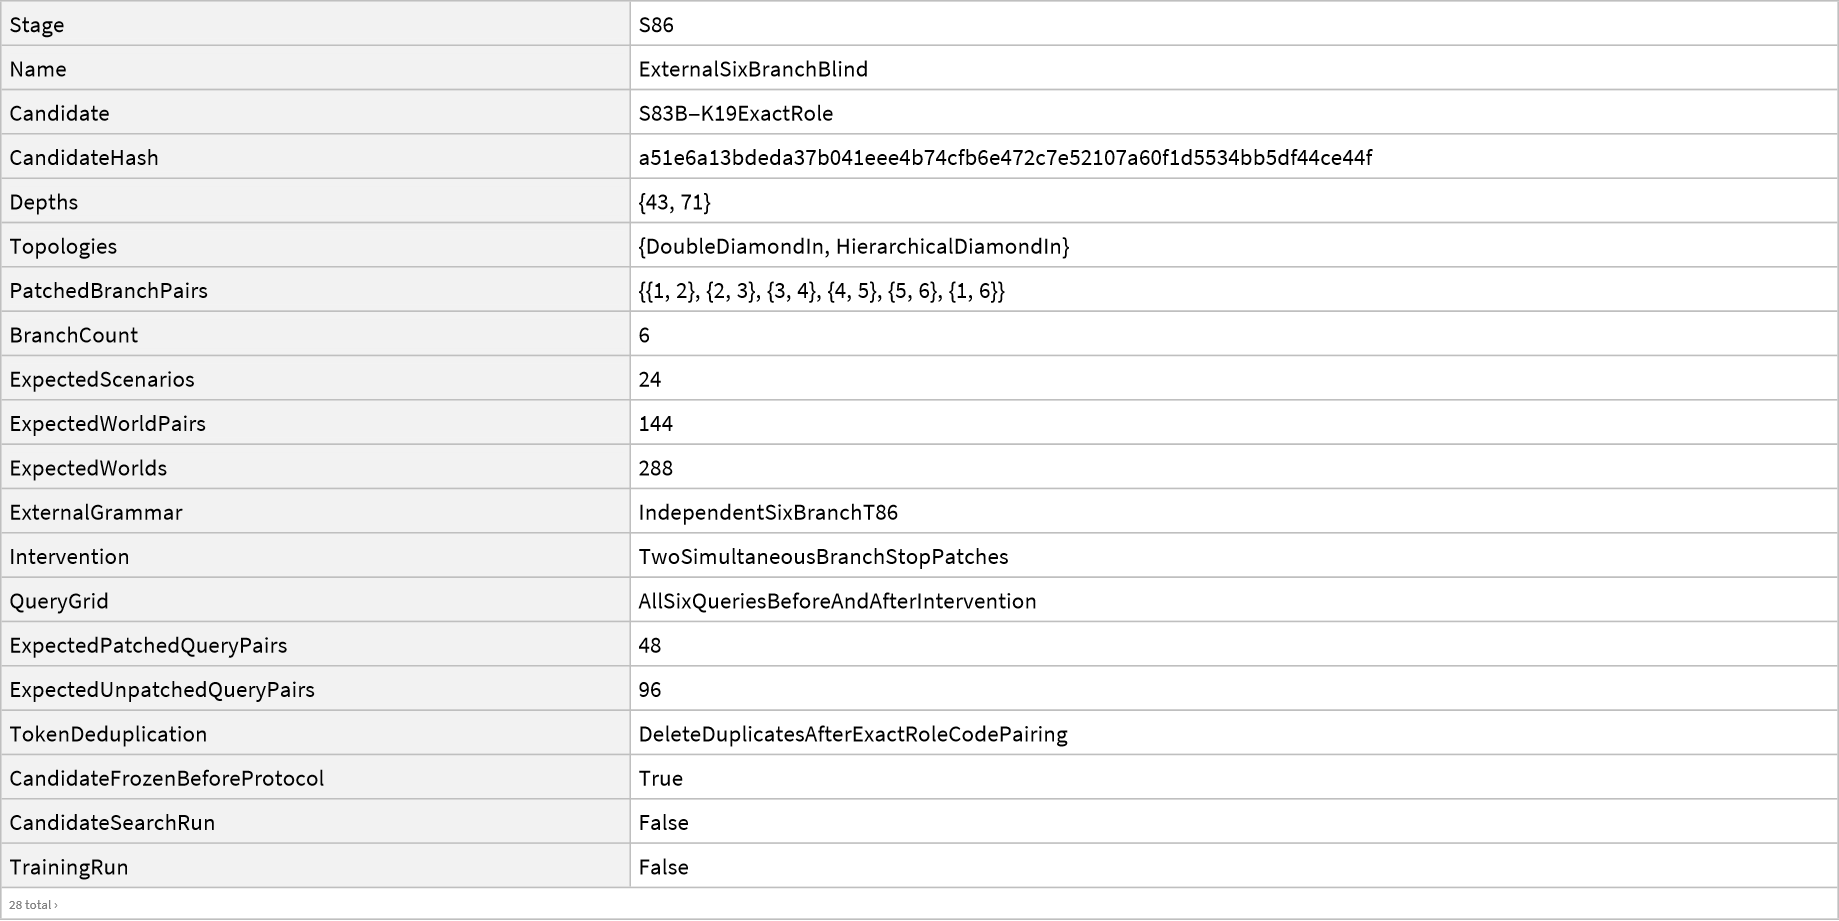

In [89]:
ClearAll[
T86,
Case86,
ReferenceAction86,
NodeRole86,
EncodePair86,
PredictTokens86,
SetAnswer86,
TopologyTransform86,
ExpectedContractions86,
BranchStopPatch86,
DoubleBranchPatch86,
PrepareWorld86,
PrepareScenario86,
S86TestDefinitionBundle
];


T86[
depth_Integer,
target_String,
answer_Integer,
seed_Integer,
branchCount_Integer
]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dummy,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,branchCount}];
v=Table[bb+200+i,{i,branchCount}];
q=Table[bb+300+i,{i,branchCount}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,branchCount}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dummy=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,branchCount]]];
main=Join[
P59[q[[i]],r1,depth,ib+1000000],
P59[q[[i]],r2,depth,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,depth+1,ib+3000000]
];
perm=If[
target==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dummy]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,branchCount}
];
{{Union[e],q,K,v,c,f},answer}
];

Case86[depth_Integer,answer_Integer,target_String]:=
T86[depth,target,answer,86000000+100 depth,6];

ReferenceAction86[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],branchCount,e,m,safe,u,dummy,
correct,wrong,continueEdges,stopEdges
},
branchCount=Length[x[[6]]];
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dummy=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,branchCount]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dummy]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],"Stop",
True,"Undefined"
]
];

NodeRole86[originalNode_,case_List,answer_Integer]:=Module[
{x,branchCount,m,correct,wrong,dummy,querySources,queryBranch,role},
x=case[[1]];
branchCount=Length[x[[6]]];
m=x[[6,answer]];
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,branchCount]]];
dummy=m+3;
querySources={m,m+1,m+2};
queryBranch=Union[querySources,{correct,wrong,dummy}];
role=Which[
SameQ[originalNode,m],"QueriedDecision",
MemberQ[querySources,originalNode],"QueriedMediatorSource",
SameQ[originalNode,correct],"QueriedCorrectDestination",
SameQ[originalNode,wrong],"QueriedWrongDestination",
SameQ[originalNode,dummy],"QueriedDummyDestination",
MemberQ[x[[6]],originalNode],"OtherDecision",
MemberQ[x[[5]],originalNode],"OtherAnswerDestination",
True,"OtherReject"
];
<|
"Role"->role,
"QueryBranchRelated"->MemberQ[queryBranch,originalNode]
|>
];

EncodePair86[pair_List]:=Module[{encoded},
encoded=First@EncodeRows75[
{<|
"Grammar"->"S86BlindObservation",
"Depth"->0,"Answer"->0,"Target"->"Unlabeled",
"StatePairs"->{pair}
|>},
frozenCandidate83B["EncoderParams"],
frozenCandidate83B["K"]
];
First[encoded["Codes"]]
];

PredictTokens86[tokens_List]:=If[
AnyTrue[tokens,MemberQ[frozenCandidate83B["Policy"],#]&],
"Continue",
"Stop"
];

SetAnswer86[c_List,answer_Integer]:={c[[1]],answer};

TopologyTransform86[topology_String,c_List]:=Switch[
topology,
"DoubleDiamondIn",DoubleDiamondIn79[c],
"HierarchicalDiamondIn",HierarchicalDiamondIn80[c],
_,$Failed
];

ExpectedContractions86[topology_String,baseCase_List]:=Switch[
topology,
"DoubleDiamondIn",2 DecisionIncomingEdgeCount79B[baseCase],
"HierarchicalDiamondIn",3 DecisionIncomingEdgeCount79B[baseCase],
_,Missing["UnknownTopology"]
];

BranchStopPatch86[c_List,branch_Integer]:=Module[
{x,branchCount,e,m,safe,u,dummy,correct,wrong,remove,add},
x=c[[1]];
branchCount=Length[x[[6]]];
e=x[[1]];
m=x[[6,branch]];
safe=m+1;
u=m+2;
dummy=m+3;
correct=x[[5,branch]];
wrong=x[[5,1+Mod[branch,branchCount]]];
remove={
DirectedEdge[m,correct],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
};
add={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dummy]
};
<|
"Remove"->remove,
"Add"->add,
"ValidOnInput"->And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
]
|>
];

DoubleBranchPatch86[c_List,branches_List]:=Module[
{parts,remove,add},
parts=BranchStopPatch86[c,#]&/@branches;
remove=DeleteDuplicates@Flatten[Lookup[parts,"Remove"],1];
add=DeleteDuplicates@Flatten[Lookup[parts,"Add"],1];
<|
"Remove"->remove,
"Add"->add,
"Branches"->branches,
"ComponentPatchesValid"->And@@Lookup[parts,"ValidOnInput"],
"NoCrossBranchConflict"->Intersection[remove,add]==={},
"ExpectedEditCount"->And[Length[remove]===6,Length[add]===6]
|>
];

PrepareWorld86[
topology_String,
depth_Integer,
patchedBranches_List,
graphCondition_String,
answer_Integer,
target_String,
baseCase_List
]:=Module[
{
topologyCase,canonicalization,canonicalCase,expectedContractions,
traceSeconds,trace,levels,pack,vertexList,packedNodes,
observations,originalNode,pair,roleInfo,rawTokens,tokens,prediction
},
topologyCase=TopologyTransform86[topology,baseCase];
canonicalization=CanonicalizePrivateDiamonds79B[topologyCase];
canonicalCase=canonicalization["Case"];
expectedContractions=ExpectedContractions86[topology,baseCase];
{traceSeconds,trace}=AbsoluteTiming[RejectTrace78[canonicalCase]];
levels=SigLevels61[canonicalCase,3];
pack=Pack60[canonicalCase];
vertexList=pack[[12]];
packedNodes=If[
Length[trace["Rejects"]]===0,
{},
DeleteDuplicates[trace["Rejects"][[All,2]]]
];
observations=Map[
Function[packedNode,
originalNode=vertexList[[packedNode]];
pair={Lookup[levels[[3]],packedNode],Lookup[levels[[4]],packedNode]};
roleInfo=NodeRole86[originalNode,canonicalCase,answer];
<|
"Role"->roleInfo["Role"],
"QueryBranchRelated"->roleInfo["QueryBranchRelated"],
"Code"->EncodePair86[pair]
|>
],
packedNodes
];
rawTokens=({#1["Role"],#1["Code"]}&)/@observations;
tokens=DeleteDuplicates[rawTokens];
prediction=PredictTokens86[tokens];
<|
"Topology"->topology,
"Depth"->depth,
"PatchedBranches"->patchedBranches,
"GraphCondition"->graphCondition,
"Answer"->answer,
"Target"->target,
"ReferenceAction"->ReferenceAction86[canonicalCase],
"BranchCount"->Length[canonicalCase[[1,6]]],
"Prediction"->prediction,
"Correct"->SameQ[prediction,target],
"TopologyGraphHash"->Hash[topologyCase[[1,1]],"SHA256","HexString"],
"CanonicalGraphHash"->Hash[canonicalCase[[1,1]],"SHA256","HexString"],
"CanonicalCaseExactlyBase"->SameQ[canonicalCase,baseCase],
"Contractions"->canonicalization["Contractions"],
"ExpectedContractions"->expectedContractions,
"ContractionCountCorrect"->SameQ[
canonicalization["Contractions"],expectedContractions
],
"ProtectedNodesPreserved"->canonicalization["ProtectedNodesPreserved"],
"StateObservationCount"->Length[observations],
"RawTokenCount"->Length[rawTokens],
"TokenCount"->Length[tokens],
"DuplicateTokensRemoved"->Length[rawTokens]-Length[tokens],
"PolicyHitTokens"->Intersection[tokens,frozenCandidate83B["Policy"]],
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],
"Rounds"->trace["Rounds"],
"TraceSeconds"->traceSeconds
|>
];

PrepareScenario86[
topology_String,depth_Integer,patchedBranches_List
]:=Module[
{
branchCount=6,seedCase,patch,hybridSeed,baseWorlds,hybridWorlds,
worldPairs,baseGraphHashes,hybridGraphHashes
},
seedCase=Case86[depth,1,"Continue"];
patch=DoubleBranchPatch86[seedCase,patchedBranches];
hybridSeed=ApplyEdgePatch81[seedCase,patch];
If[SameQ[hybridSeed,$Failed],Return[$Failed]];
baseWorlds=Table[
PrepareWorld86[
topology,depth,patchedBranches,"Baseline",answer,"Continue",
SetAnswer86[seedCase,answer]
],
{answer,Range[branchCount]}
];
hybridWorlds=Table[
PrepareWorld86[
topology,depth,patchedBranches,"DoubleIntervention",answer,
If[MemberQ[patchedBranches,answer],"Stop","Continue"],
SetAnswer86[hybridSeed,answer]
],
{answer,Range[branchCount]}
];
worldPairs=MapThread[
Function[{base,hybrid},
<|
"Answer"->base["Answer"],
"PatchedQuery"->MemberQ[patchedBranches,base["Answer"]],
"SameQuery"->SameQ[base["Answer"],hybrid["Answer"]],
"ReferenceRelationCorrect"->If[
MemberQ[patchedBranches,base["Answer"]],
And[
SameQ[base["ReferenceAction"],"Continue"],
SameQ[hybrid["ReferenceAction"],"Stop"]
],
And[
SameQ[base["ReferenceAction"],"Continue"],
SameQ[hybrid["ReferenceAction"],"Continue"]
]
],
"PredictionRelationCorrect"->If[
MemberQ[patchedBranches,base["Answer"]],
And[
SameQ[base["Prediction"],"Continue"],
SameQ[hybrid["Prediction"],"Stop"]
],
And[
SameQ[base["Prediction"],"Continue"],
SameQ[hybrid["Prediction"],"Continue"]
]
],
"PairCorrect"->And[TrueQ[base["Correct"]],TrueQ[hybrid["Correct"]]],
"BaselineWorld"->base,
"InterventionWorld"->hybrid
|>
],
{baseWorlds,hybridWorlds}
];
baseGraphHashes=Lookup[baseWorlds,"TopologyGraphHash"];
hybridGraphHashes=Lookup[hybridWorlds,"TopologyGraphHash"];
<|
"Topology"->topology,
"Depth"->depth,
"PatchedBranches"->patchedBranches,
"PatchComponentValidity"->patch["ComponentPatchesValid"],
"PatchNoConflict"->patch["NoCrossBranchConflict"],
"PatchEditCountCorrect"->patch["ExpectedEditCount"],
"BaselineSameGraphAcrossQueries"->SameQ@@baseGraphHashes,
"InterventionSameGraphAcrossQueries"->SameQ@@hybridGraphHashes,
"PatchChangesGraph"->UnsameQ[First[baseGraphHashes],First[hybridGraphHashes]],
"ReferenceRelationsCorrect"->And@@Lookup[worldPairs,"ReferenceRelationCorrect"],
"PredictionRelationsCorrect"->And@@Lookup[worldPairs,"PredictionRelationCorrect"],
"AllTwelveWorldsCorrect"->And@@Join[
Lookup[baseWorlds,"Correct"],Lookup[hybridWorlds,"Correct"]
],
"WorldPairs"->worldPairs,
"BaselineWorlds"->baseWorlds,
"InterventionWorlds"->hybridWorlds
|>
];

S86TestDefinitionBundle[]:={
DownValues[T86],DownValues[Case86],DownValues[ReferenceAction86],
DownValues[NodeRole86],DownValues[EncodePair86],DownValues[PredictTokens86],
DownValues[SetAnswer86],DownValues[TopologyTransform86],
DownValues[ExpectedContractions86],DownValues[BranchStopPatch86],
DownValues[DoubleBranchPatch86],DownValues[PrepareWorld86],
DownValues[PrepareScenario86]
};

blindDepths86={43,71};
blindTopologies86={"DoubleDiamondIn","HierarchicalDiamondIn"};
blindPatchedBranchPairs86={{1,2},{2,3},{3,4},{4,5},{5,6},{1,6}};

protocol86=<|
"Stage"->"S86",
"Name"->"ExternalSixBranchBlind",
"Candidate"->"S83B-K19ExactRole",
"CandidateHash"->candidateHashLoaded86,
"Depths"->blindDepths86,
"Topologies"->blindTopologies86,
"PatchedBranchPairs"->blindPatchedBranchPairs86,
"BranchCount"->6,
"ExpectedScenarios"->24,
"ExpectedWorldPairs"->144,
"ExpectedWorlds"->288,
"ExternalGrammar"->"IndependentSixBranchT86",
"Intervention"->"TwoSimultaneousBranchStopPatches",
"QueryGrid"->"AllSixQueriesBeforeAndAfterIntervention",
"ExpectedPatchedQueryPairs"->48,
"ExpectedUnpatchedQueryPairs"->96,
"TokenDeduplication"->"DeleteDuplicatesAfterExactRoleCodePairing",
"CandidateFrozenBeforeProtocol"->True,
"CandidateSearchRun"->False,
"TrainingRun"->False,
"HistoricalRegressionRerun"->False,
"S83BlindRerun"->False,
"S84BlindRerun"->False,
"S85BlindRerun"->False,
"S83BDevelopmentRowsRerun"->False,
"S86LabelsUsedForSelection"->False,
"NoCaseEvaluatedBeforeProtocolHash"->True
|>;

protocolHash86=Hash[Normal[protocol86],"SHA256","HexString"];
modelHashBefore86=Hash[Normal[frozen75D],"SHA256","HexString"];
candidateHashBefore86=Hash[Normal[frozenCandidate83B],"SHA256","HexString"];
coreHashBefore86=Hash[CoreDefinitionBundle86[],"SHA256","HexString"];
canonicalizerHashBefore86=canonicalizerImplementationHash79B;
interventionHashBefore86=interventionImplementationHash82;
topologyHashBefore86=Hash[
{DownValues[DoubleDiamondIn79],DownValues[HierarchicalDiamondIn80]},
"SHA256","HexString"
];
testDefinitionHashBefore86=Hash[
S86TestDefinitionBundle[],"SHA256","HexString"
];

Dataset[{Join[protocol86,<|"ProtocolHash"->protocolHash86|>]}]


Dataset[{<|Stage -> S86D, Name -> FullCombinedKFeasibilityScan, AuditOnly -> True, 
 
>     S86CCertificateHashAcknowledged -> 
 
>      945cbf88b24e0b25cfc07a23ea2d2b4cad028c5a2eb8ce5a419a4ac33d74800d, 
 
>     S86CProtocolHashAcknowledged -> 
 
>      2da68ba2a69f44f2fc367441a7bd1bfadce2801350323cdc3397d4466966636f, 
 
>     BaseCandidateHash -> 
 
>      a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     HistoricalDevelopmentRows -> 264, SixBranchDevelopmentWorlds -> 288, 
 
>     CombinedDevelopmentRows -> 552, 
 
>     CandidateKs -> 
 
>      {10, 12, 13, 14, 15, 16, 18, 20, 21, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 
 
>       35, 36, 37, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 
 
>       56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 
 
>       76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 
 
>       96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 
 
>       113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128}, 
 
>     CandidateKCount -> 113, K19ExcludedByS86C -> True, Representation -> KExactRole, 
 
>     PolicyRule -> AllContinueTokensAbsentFromEveryStopRow, 
 
>     SelectionRule -> MinimumKThenMinimumPolicyLength, 
 
>     S86LabelsUsedForDevelopment -> True, S87DataUsed -> False, 
 
>     PolicyAppliedToFrozenCandidate -> False, NewCandidateSelected -> False, 
 
>     CandidateExportAllowed -> False, CoreMayChange -> False, 
 
>     DeduplicationMayChange -> False, 
 
>     NoDevelopmentRowEvaluatedBeforeProtocolHash -> True, 
 
>     ProtocolHash -> 3faafbe4eef88369c32637b2b6b0825e288f6c40d7286db47e8739f083c3d309, 
 
>     PreflightPassed -> True|>}, TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[
 
>      String], TypeSystem`AnyType, 25], 1], <||>]
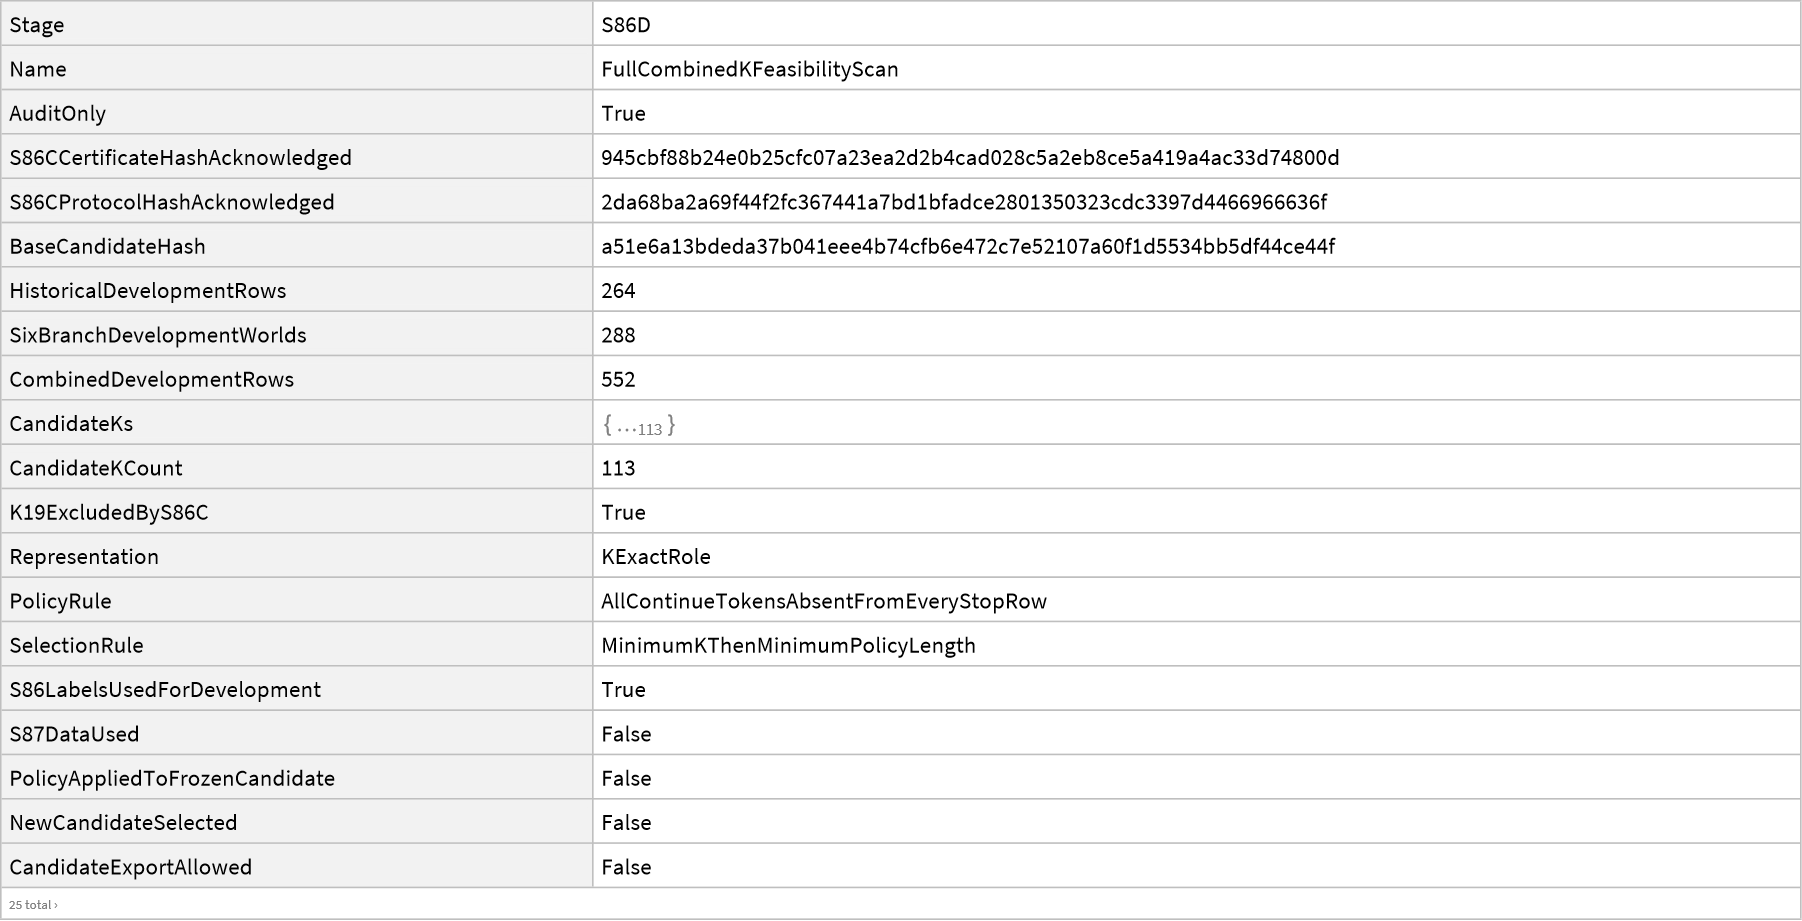

In [117]:
CaseByGrammar82C[
grammar_String,depth_Integer,answer_Integer,target_String
]:=Switch[
grammar,
"S59",Case59[depth,answer,target],
"ChainIn",Case63["ChainIn",depth,answer,target],
"SharedMerge",Case63["SharedMerge",depth,answer,target],
"ParallelIn",Case71[depth,answer,target],
"ParallelOut"|"DiamondIn"|"SharedParallelIn",
Case72B[grammar,depth,answer,target],
_,$Failed
];

NodeRole82C[originalNode_,case_List,answer_Integer]:=Module[
{x,m,correct,wrong,dummy,querySources,queryBranch,role},
x=case[[1]];
m=x[[6,answer]];
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,4]]];
dummy=m+3;
querySources={m,m+1,m+2};
queryBranch=Union[querySources,{correct,wrong,dummy}];
role=Which[
SameQ[originalNode,m],"QueriedDecision",
MemberQ[querySources,originalNode],"QueriedMediatorSource",
SameQ[originalNode,correct],"QueriedCorrectDestination",
SameQ[originalNode,wrong],"QueriedWrongDestination",
SameQ[originalNode,dummy],"QueriedDummyDestination",
MemberQ[x[[6]],originalNode],"OtherDecision",
MemberQ[x[[5]],originalNode],"OtherAnswerDestination",
True,"OtherReject"
];
<|
"Role"->role,
"QueryBranchRelated"->MemberQ[queryBranch,originalNode]
|>
];

EncodePairWithK82C[pair_List,k_Integer]:=
EncodePairWithK82C[pair,k]=Module[{encoded},
encoded=First@EncodeRows75[
{<|
"Grammar"->"S82CCapacityObservation",
"Depth"->0,"Answer"->0,"Target"->"Unlabeled",
"StatePairs"->{pair}
|>},
frozen75D["Params"],k
];
First[encoded["Codes"]]
];

StateBagComponents82C[state_]:=If[
MatchQ[state,{_Integer,_Integer}],
<|"Leaves"->{state},"Branches"->{}|>,
Module[{parts},
parts=StateBagComponents82C/@Join[
{state[[1]]},state[[2]],state[[3]]
];
<|
"Leaves"->Flatten[Lookup[parts,"Leaves"],1],
"Branches"->Join[
{{Length[state[[2]]],Length[state[[3]]]}},
Flatten[Lookup[parts,"Branches"],1]
]
|>
]
];

StateBagProfile82C[state_]:=Module[{components},
components=StateBagComponents82C[state];
{
Sort[components["Leaves"]],
Sort[components["Branches"]]
}
];

PairBagProfile82C[pair_List]:={
StateBagProfile82C[pair[[1]]],
StateBagProfile82C[pair[[2]]]
};

PrepareCapacityRow82C[
grammar_String,depth_Integer,answer_Integer,target_String,case_List
]:=Module[
{
canonicalization,canonicalCase,trace,levels,pack,vertexList,
packedNodes,observations,originalNode,pair,roleInfo
},
canonicalization=CanonicalizePrivateDiamonds79B[case];
canonicalCase=canonicalization["Case"];
trace=RejectTrace78[canonicalCase];
levels=SigLevels61[canonicalCase,3];
pack=Pack60[canonicalCase];
vertexList=pack[[12]];
packedNodes=If[
Length[trace["Rejects"]]===0,
{},
DeleteDuplicates[trace["Rejects"][[All,2]]]
];
observations=Map[
Function[packedNode,
originalNode=vertexList[[packedNode]];
pair={
Lookup[levels[[3]],packedNode],
Lookup[levels[[4]],packedNode]
};
roleInfo=NodeRole82C[originalNode,canonicalCase,answer];
<|
"Role"->roleInfo["Role"],
"QueryBranchRelated"->roleInfo["QueryBranchRelated"],
"RawPair"->pair,
"RawPairHash"->Hash[pair,"SHA256","HexString"],
"BagProfile"->PairBagProfile82C[pair]
|>
],
packedNodes
];
<|
"Grammar"->grammar,
"Depth"->depth,
"Answer"->answer,
"Target"->target,
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],
"Observations"->observations
|>
];

CandidateToken82C[
observation_Association,
candidate_Association
]:=Module[{role,type,k,pair,profile},
role=observation["Role"];
type=candidate["Type"];
k=candidate["K"];
pair=observation["RawPair"];
profile=observation["BagProfile"];
Switch[
type,
"KExactRole",{role,EncodePairWithK82C[pair,k]},
"CodePlusBagProfile",{role,EncodePairWithK82C[pair,k],profile},
"BagProfileOnly",{role,profile},
"RawPair",{role,pair},
_,$Failed
]
];

TokenizedRows82C[rows_List,candidate_Association]:=Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Tokens"->DeleteDuplicates[
CandidateToken82C[#,candidate]&/@row["Observations"]
]
|>
]
],
rows
];

SafePolicy82C[tokenRows_List]:=Module[
{continueRows,stopRows,continueTokens,stopTokens},
continueRows=Select[tokenRows,SameQ[#["Target"],"Continue"]&];
stopRows=Select[tokenRows,SameQ[#["Target"],"Stop"]&];
continueTokens=Union@@Lookup[continueRows,"Tokens"];
stopTokens=Union@@Lookup[stopRows,"Tokens"];
Complement[continueTokens,stopTokens]
];

ScoreRows82C[tokenRows_List,policy_List]:=Count[
tokenRows,
row_/;SameQ[
If[AnyTrue[row["Tokens"],MemberQ[policy,#]&],"Continue","Stop"],
row["Target"]
]
];ClearAll[
TopologyTransform83A,
SetAnswer83A,
PrepareAuditRow83A,
BuildHybridRows83A,
ScopedObservations83A,
ScopedTokenRows83A,
EvaluateScope83A,
AuditDefinitionBundle83A
];

TopologyTransform83A[topology_String,c_List]:=Switch[
topology,
"DoubleDiamondIn",DoubleDiamondIn79[c],
"HierarchicalDiamondIn",HierarchicalDiamondIn80[c],
_,$Failed
];

SetAnswer83A[c_List,answer_Integer]:={c[[1]],answer};

PrepareAuditRow83A[
topology_String,
depth_Integer,
patchedBranch_Integer,
answer_Integer,
target_String,
worldType_String,
baseCase_List
]:=Join[
PrepareCapacityRow82C[
"S83A-"<>worldType,
depth,
answer,
target,
TopologyTransform83A[topology,baseCase]
],
<|
"Topology"->topology,
"PatchedBranch"->patchedBranch,
"WorldType"->worldType
|>
];

BuildHybridRows83A[
topology_String,depth_Integer,patchedBranch_Integer
]:=Module[
{seedCase,hybridCase,factualAnswer,factualBase,counterfactualBase},
seedCase=Case59[depth,patchedBranch,"Continue"];
hybridCase=ApplyEdgePatch81[
seedCase,LocalMediatorPatch82[depth,patchedBranch]
];
factualAnswer=1+Mod[patchedBranch,4];
factualBase=SetAnswer83A[hybridCase,factualAnswer];
counterfactualBase=SetAnswer83A[hybridCase,patchedBranch];
{
PrepareAuditRow83A[
topology,depth,patchedBranch,factualAnswer,"Continue",
"HybridFactual",factualBase
],
PrepareAuditRow83A[
topology,depth,patchedBranch,patchedBranch,"Stop",
"HybridCounterfactual",counterfactualBase
]
}
];

ScopedObservations83A[row_Association,scope_Association]:=Switch[
scope["Type"],
"All",row["Observations"],
"QueryRelated",Select[
row["Observations"],TrueQ[#1["QueryBranchRelated"]]&
],
"RoleSubset",Select[
row["Observations"],MemberQ[scope["Roles"],#1["Role"]]&
],
_,{}
];

ScopedTokenRows83A[rows_List,scope_Association]:=Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target","Topology",
"PatchedBranch","WorldType"}],
<|
"Tokens"->DeleteDuplicates[
({#1["Role"],EncodePairWithK82C[#1["RawPair"],10]}&)/@
ScopedObservations83A[row,scope]
]
|>
]
],
rows
];

EvaluateScope83A[scope_Association]:=Module[
{legacyTokens,stressTokens,hybridTokens,allTokens,policy},
legacyTokens=ScopedTokenRows83A[legacyRows83A,scope];
stressTokens=ScopedTokenRows83A[stressRows83A,scope];
hybridTokens=ScopedTokenRows83A[hybridRows83A,scope];
allTokens=Join[legacyTokens,stressTokens,hybridTokens];
policy=SafePolicy82C[allTokens];
Join[
scope,
<|
"Policy"->policy,
"PolicyLength"->Length[policy],
"LegacyScore"->ScoreRows82C[legacyTokens,policy],
"LegacyCases"->Length[legacyTokens],
"StressScore"->ScoreRows82C[stressTokens,policy],
"StressCases"->Length[stressTokens],
"HybridFactualScore"->ScoreRows82C[
Select[hybridTokens,SameQ[#1["Target"],"Continue"]&],policy
],
"HybridFactualCases"->Count[
hybridTokens,row_/;SameQ[row["Target"],"Continue"]
],
"HybridCounterfactualScore"->ScoreRows82C[
Select[hybridTokens,SameQ[#1["Target"],"Stop"]&],policy
],
"HybridCounterfactualCases"->Count[
hybridTokens,row_/;SameQ[row["Target"],"Stop"]
],
"AllDevelopmentScore"->ScoreRows82C[allTokens,policy],
"AllDevelopmentCases"->Length[allTokens],
"AddedTokensVsFrozen"->Length[Complement[
policy,frozenCandidate82C["Policy"]
]],
"RemovedTokensVsFrozen"->Length[Complement[
frozenCandidate82C["Policy"],policy
]],
"Perfect"->SameQ[ScoreRows82C[allTokens,policy],Length[allTokens]]
|>
]
];

AuditDefinitionBundle83A[]:={
DownValues[TopologyTransform83A],DownValues[SetAnswer83A],
DownValues[PrepareAuditRow83A],DownValues[BuildHybridRows83A],
DownValues[ScopedObservations83A],DownValues[ScopedTokenRows83A],
DownValues[EvaluateScope83A]
};

legacyGrammars83A={
"S59","ChainIn","SharedMerge","ParallelIn",
"ParallelOut","DiamondIn","SharedParallelIn"
};
legacyDepths83A={2,5,9,15};
stressDepths83A={2,5};
auditDepths83A={23,47};
auditTopologies83A={"DoubleDiamondIn","HierarchicalDiamondIn"};
auditBranches83A=Range[4];

queryRoles83A={
"QueriedDecision","QueriedMediatorSource",
"QueriedCorrectDestination","QueriedWrongDestination",
"QueriedDummyDestination"
};

scopeCandidates83A=Join[
{
<|"Name"->"AllTokens","Type"->"All","Roles"->All,"Priority"->0|>,
<|"Name"->"QueryRelatedOnly","Type"->"QueryRelated",
"Roles"->queryRoles83A,"Priority"->1|>
},
MapIndexed[
Function[{roles,index},<|
"Name"->("RoleSubset"<>ToString[First[index]]),
"Type"->"RoleSubset",
"Roles"->roles,
"Priority"->10+Length[roles]
|>],
Rest@Subsets[queryRoles83A]
]
];ClearAll[
EncodePairForK86B,
TokenizeObservations86B,
TokenizeHistoricalRow86B,
PrepareDevelopmentWorld86B,
PrepareDevelopmentScenario86B,
BuildHistoricalRows86B,
SafePolicy86B,
ScoreTokenRows86B,
PolicyPrediction86B,
S86BDefinitionBundle
];

encodeCache86B=<||>;

EncodePairForK86B[pair_List]:=Module[{key,cached,encoded,code},
key=Hash[pair,"SHA256","HexString"];
cached=Lookup[encodeCache86B,key,Missing["NotCached"]];
If[!MissingQ[cached],Return[cached]];
encoded=First@EncodeRows75[
{<|
"Grammar"->"S86BDevelopmentObservation",
"Depth"->0,"Answer"->0,"Target"->"Unlabeled",
"StatePairs"->{pair}
|>},
frozenCandidate83B["EncoderParams"],
19
];
code=First[encoded["Codes"]];
AssociateTo[encodeCache86B,key->code];
code
];

TokenizeObservations86B[observations_List]:=DeleteDuplicates[
({#1["Role"],EncodePairForK86B[#1["RawPair"]]}&)/@observations
];

TokenizeHistoricalRow86B[row_Association]:=Join[
KeyTake[row,{"Grammar","Depth","Answer","Target","Topology",
"PatchedBranch","WorldType"}],
<|"Source"->"Historical264","Tokens"->
TokenizeObservations86B[row["Observations"]]|>
];

PrepareDevelopmentWorld86B[
topology_String,
depth_Integer,
patchedBranches_List,
graphCondition_String,
answer_Integer,
target_String,
baseCase_List
]:=Module[
{
topologyCase,canonicalization,canonicalCase,traceSeconds,trace,
levels,pack,vertexList,packedNodes,observations,originalNode,pair,roleInfo
},
topologyCase=TopologyTransform86[topology,baseCase];
canonicalization=CanonicalizePrivateDiamonds79B[topologyCase];
canonicalCase=canonicalization["Case"];
{traceSeconds,trace}=AbsoluteTiming[RejectTrace78[canonicalCase]];
levels=SigLevels61[canonicalCase,3];
pack=Pack60[canonicalCase];
vertexList=pack[[12]];
packedNodes=If[
Length[trace["Rejects"]]===0,{},DeleteDuplicates[trace["Rejects"][[All,2]]]
];
observations=Map[
Function[packedNode,
originalNode=vertexList[[packedNode]];
pair={Lookup[levels[[3]],packedNode],Lookup[levels[[4]],packedNode]};
roleInfo=NodeRole86[originalNode,canonicalCase,answer];
<|"Role"->roleInfo["Role"],"RawPair"->pair|>
],
packedNodes
];
<|
"Source"->"S86Development288",
"Topology"->topology,
"Depth"->depth,
"PatchedBranches"->patchedBranches,
"GraphCondition"->graphCondition,
"Answer"->answer,
"Target"->target,
"ReferenceAction"->ReferenceAction86[canonicalCase],
"BranchCount"->Length[canonicalCase[[1,6]]],
"Observations"->observations,
"CanonicalCaseExactlyBase"->SameQ[canonicalCase,baseCase],
"ProtectedNodesPreserved"->canonicalization["ProtectedNodesPreserved"],
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],
"TraceSeconds"->traceSeconds
|>
];

PrepareDevelopmentScenario86B[
topology_String,depth_Integer,patchedBranches_List
]:=Module[{seedCase,patch,hybridSeed,baseline,intervention},
seedCase=Case86[depth,1,"Continue"];
patch=DoubleBranchPatch86[seedCase,patchedBranches];
hybridSeed=ApplyEdgePatch81[seedCase,patch];
If[SameQ[hybridSeed,$Failed],Return[$Failed]];
baseline=Table[
PrepareDevelopmentWorld86B[
topology,depth,patchedBranches,"Baseline",answer,"Continue",
SetAnswer86[seedCase,answer]
],
{answer,Range[6]}
];
intervention=Table[
PrepareDevelopmentWorld86B[
topology,depth,patchedBranches,"DoubleIntervention",answer,
If[MemberQ[patchedBranches,answer],"Stop","Continue"],
SetAnswer86[hybridSeed,answer]
],
{answer,Range[6]}
];
<|"Topology"->topology,"Depth"->depth,
"PatchedBranches"->patchedBranches,
"Worlds"->Join[baseline,intervention]|>
];

BuildHistoricalRows86B[]:=Module[{legacy,stress,hybrid},
legacy=Flatten[
Table[
PrepareCapacityRow82C[
grammar,depth,answer,target,
CaseByGrammar82C[grammar,depth,answer,target]
],
{grammar,legacyGrammars83A},{depth,legacyDepths83A},
{answer,Range[4]},{target,{"Continue","Stop"}}
],3
];
stress=Flatten[
Table[
PrepareCapacityRow82C[
"LocalMediatorDevelopment",depth,answer,"Stop",
ApplyEdgePatch81[
Case59[depth,answer,"Continue"],LocalMediatorPatch82[depth,answer]
]
],
{depth,stressDepths83A},{answer,Range[4]}
],1
];
hybrid=Flatten[
Table[
BuildHybridRows83A[topology,depth,patchedBranch],
{topology,auditTopologies83A},{depth,auditDepths83A},
{patchedBranch,auditBranches83A}
],3
];
<|"Legacy"->legacy,"Stress"->stress,"Hybrid"->hybrid|>
];

PolicyPrediction86B[tokens_List,policy_List]:=If[
AnyTrue[tokens,MemberQ[policy,#]&],"Continue","Stop"
];

ScoreTokenRows86B[rows_List,policy_List]:=Count[
rows,row_/;SameQ[PolicyPrediction86B[row["Tokens"],policy],row["Target"]]
];

SafePolicy86B[rows_List]:=Module[
{continueRows,stopRows,continueTokens,stopTokens},
continueRows=Select[rows,SameQ[#1["Target"],"Continue"]&];
stopRows=Select[rows,SameQ[#1["Target"],"Stop"]&];
continueTokens=Union@@Lookup[continueRows,"Tokens"];
stopTokens=Union@@Lookup[stopRows,"Tokens"];
Complement[continueTokens,stopTokens]
];

S86BDefinitionBundle[]:={
DownValues[CaseByGrammar82C],
DownValues[PairBagProfile82C],
DownValues[PrepareCapacityRow82C],
DownValues[TopologyTransform83A],
DownValues[SetAnswer83A],
DownValues[PrepareAuditRow83A],
DownValues[BuildHybridRows83A],
DownValues[EncodePairForK86B],
DownValues[TokenizeObservations86B],
DownValues[TokenizeHistoricalRow86B],
DownValues[PrepareDevelopmentWorld86B],
DownValues[PrepareDevelopmentScenario86B],
DownValues[BuildHistoricalRows86B],
DownValues[SafePolicy86B],
DownValues[ScoreTokenRows86B],
DownValues[PolicyPrediction86B]
};ClearAll[
EncodePairForK86D,
TokenizeRawRow86D,
SafePolicy86D,
PolicyPrediction86D,
ScoreRows86D,
EvaluateK86D,
S86DDefinitionBundle
];

encodeCache86D=<||>;

EncodePairForK86D[pair_List,k_Integer]:=Module[{key,cached,encoded,code},
key=Hash[{pair,k},"SHA256","HexString"];
cached=Lookup[encodeCache86D,key,Missing["NotCached"]];
If[!MissingQ[cached],Return[cached]];
encoded=First@EncodeRows75[
{<|"Grammar"->"S86DFullCombinedObservation","Depth"->0,
"Answer"->0,"Target"->"Unlabeled","StatePairs"->{pair}|>},
frozenCandidate83B["EncoderParams"],k
];
code=First[encoded["Codes"]];
AssociateTo[encodeCache86D,key->code];
code
];

TokenizeRawRow86D[row_Association,k_Integer]:=Join[
KeyTake[row,{"Source","Grammar","Topology","Depth","Answer","Target",
"PatchedBranch","PatchedBranches","WorldType","GraphCondition"}],
<|"Tokens"->DeleteDuplicates[
({#1["Role"],EncodePairForK86D[#1["RawPair"],k]}&)/@row["Observations"]
]|>
];

SafePolicy86D[rows_List]:=Module[{continueTokens,stopTokens},
continueTokens=Union@@Lookup[
Select[rows,SameQ[#1["Target"],"Continue"]&],"Tokens"
];
stopTokens=Union@@Lookup[
Select[rows,SameQ[#1["Target"],"Stop"]&],"Tokens"
];
Complement[continueTokens,stopTokens]
];

PolicyPrediction86D[tokens_List,policy_List]:=If[
AnyTrue[tokens,MemberQ[policy,#]&],"Continue","Stop"
];

ScoreRows86D[rows_List,policy_List]:=Count[
rows,row_/;SameQ[PolicyPrediction86D[row["Tokens"],policy],row["Target"]]
];

EvaluateK86D[k_Integer]:=Module[
{historical,six,combined,policy,hScore,sScore,cScore,shared},
historical=TokenizeRawRow86D[#,k]&/@historicalRawRows86D;
six=TokenizeRawRow86D[#,k]&/@sixRawRows86D;
combined=Join[historical,six];
policy=SafePolicy86D[combined];
hScore=ScoreRows86D[historical,policy];
sScore=ScoreRows86D[six,policy];
cScore=ScoreRows86D[combined,policy];
shared=Intersection[
Union@@Lookup[Select[combined,SameQ[#1["Target"],"Continue"]&],"Tokens"],
Union@@Lookup[Select[combined,SameQ[#1["Target"],"Stop"]&],"Tokens"]
];
<|
"K"->k,"HistoricalScore"->hScore,"SixBranchScore"->sScore,
"CombinedScore"->cScore,"CombinedPerfect"->SameQ[cScore,552],
"SharedTokens"->Length[shared],"PolicyLength"->Length[policy],
"Policy"->policy
|>
];

S86DDefinitionBundle[]:={
DownValues[CaseByGrammar82C],DownValues[PairBagProfile82C],
DownValues[PrepareCapacityRow82C],DownValues[TopologyTransform83A],
DownValues[SetAnswer83A],DownValues[PrepareAuditRow83A],
DownValues[BuildHybridRows83A],DownValues[PrepareDevelopmentWorld86B],
DownValues[PrepareDevelopmentScenario86B],
DownValues[BuildHistoricalRows86B],DownValues[EncodePairForK86D],
DownValues[TokenizeRawRow86D],DownValues[SafePolicy86D],
DownValues[PolicyPrediction86D],DownValues[ScoreRows86D],
DownValues[EvaluateK86D]
};

expectedS86CCertificateHash86D=
"945cbf88b24e0b25cfc07a23ea2d2b4cad028c5a2eb8ce5a419a4ac33d74800d";
expectedS86CProtocolHash86D=
"2da68ba2a69f44f2fc367441a7bd1bfadce2801350323cdc3397d4466966636f";
expectedBaseCandidateHash86D=
"a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f";

localPerfectKs86D={
10,12,13,14,15,16,18,20,21,23,24,25,26,27,28,29,30,31,32,33,
35,36,37,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,
56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,
76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,
96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,
112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128
};

protocol86D=<|
"Stage"->"S86D",
"Name"->"FullCombinedKFeasibilityScan",
"AuditOnly"->True,
"S86CCertificateHashAcknowledged"->expectedS86CCertificateHash86D,
"S86CProtocolHashAcknowledged"->expectedS86CProtocolHash86D,
"BaseCandidateHash"->expectedBaseCandidateHash86D,
"HistoricalDevelopmentRows"->264,
"SixBranchDevelopmentWorlds"->288,
"CombinedDevelopmentRows"->552,
"CandidateKs"->localPerfectKs86D,
"CandidateKCount"->Length[localPerfectKs86D],
"K19ExcludedByS86C"->!MemberQ[localPerfectKs86D,19],
"Representation"->"KExactRole",
"PolicyRule"->"AllContinueTokensAbsentFromEveryStopRow",
"SelectionRule"->"MinimumKThenMinimumPolicyLength",
"S86LabelsUsedForDevelopment"->True,
"S87DataUsed"->False,
"PolicyAppliedToFrozenCandidate"->False,
"NewCandidateSelected"->False,
"CandidateExportAllowed"->False,
"CoreMayChange"->False,
"DeduplicationMayChange"->False,
"NoDevelopmentRowEvaluatedBeforeProtocolHash"->True
|>;

protocolHash86D=Hash[Normal[protocol86D],"SHA256","HexString"];
modelHashBefore86D=Hash[Normal[frozen75D],"SHA256","HexString"];
candidateHashBefore86D=Hash[Normal[frozenCandidate83B],"SHA256","HexString"];
coreHashBefore86D=Hash[CoreDefinitionBundle86[],"SHA256","HexString"];
canonicalizerHashBefore86D=canonicalizerImplementationHash79B;
interventionHashBefore86D=interventionImplementationHash82;
definitionHashBefore86D=Hash[S86DDefinitionBundle[],"SHA256","HexString"];

preflightPassed86D=And[
TrueQ[preflightPassed86],
SameQ[candidateHashBefore86D,expectedBaseCandidateHash86D],
SameQ[Length[localPerfectKs86D],113],
!MemberQ[localPerfectKs86D,19]
];

If[!TrueQ[preflightPassed86D],
Print["S86D aborted: locked protocol/candidate preflight failed."];Abort[]
];

Dataset[{Join[protocol86D,<|
"ProtocolHash"->protocolHash86D,"PreflightPassed"->preflightPassed86D
|>]}]


Dataset[{<|HistoricalLegacyRows -> 224, HistoricalStressRows -> 8, 
 
>     HistoricalHybridRows -> 32, HistoricalRows -> 264, SixBranchScenarios -> 24, 
 
>     SixBranchWorlds -> 288, CombinedRows -> 552, 
 
>     HistoricalRowsTerminatedNaturally -> 264, HistoricalRowsHitSafetyCap -> 0, 
 
>     SixReferenceActionsCorrect -> 288, SixCanonicalExact -> 288, 
 
>     SixProtectedNodesPreserved -> 288, SixRowsTerminatedNaturally -> 288, 
 
>     SixRowsHitSafetyCap -> 0, SixTotalTraceSeconds -> 122.383|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{HistoricalLegacyRows, HistoricalStressRows, 
 
>      HistoricalHybridRows, HistoricalRows, SixBranchScenarios, SixBranchWorlds, 
 
>      CombinedRows, HistoricalRowsTerminatedNaturally, HistoricalRowsHitSafetyCap, 
 
>      SixReferenceActionsCorrect, SixCanonicalExact, SixProtectedNodesPreserved, 
 
>      SixRowsTerminatedNaturally, SixRowsHitSafetyCap, SixTotalTraceSeconds}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Real]}], 1], 
 
>   <||>]
Dataset[{<|K -> 10, HistoricalScore -> 208, SixBranchScore -> 52, CombinedScore -> 260, 
 
>     CombinedPerfect -> False, SharedTokens -> 6, PolicyLength -> 7|>, 
 
>    <|K -> 12, HistoricalScore -> 220, SixBranchScore -> 48, CombinedScore -> 268, 
 
>     CombinedPerfect -> False, SharedTokens -> 8, PolicyLength -> 14|>, 
 
>    <|K -> 13, HistoricalScore -> 232, SixBranchScore -> 172, CombinedScore -> 404, 
 
>     CombinedPerfect -> False, SharedTokens -> 11, PolicyLength -> 26|>, 
 
>    <|K -> 14, HistoricalScore -> 244, SixBranchScore -> 276, CombinedScore -> 520, 
 
>     CombinedPerfect -> False, SharedTokens -> 5, PolicyLength -> 26|>, 
 
>    <|K -> 15, HistoricalScore -> 248, SixBranchScore -> 232, CombinedScore -> 480, 
 
>     CombinedPerfect -> False, SharedTokens -> 7, PolicyLength -> 18|>, 
 
>    <|K -> 16, HistoricalScore -> 228, SixBranchScore -> 240, CombinedScore -> 468, 
 
>     CombinedPerfect -> False, SharedTokens -> 7, PolicyLength -> 24|>, 
 
>    <|K -> 18, HistoricalScore -> 224, SixBranchScore -> 196, CombinedScore -> 420, 
 
>     CombinedPerfect -> False, SharedTokens -> 10, PolicyLength -> 20|>, 
 
>    <|K -> 20, HistoricalScore -> 240, SixBranchScore -> 168, CombinedScore -> 408, 
 
>     CombinedPerfect -> False, SharedTokens -> 8, PolicyLength -> 21|>, 
 
>    <|K -> 21, HistoricalScore -> 252, SixBranchScore -> 276, CombinedScore -> 528, 
 
>     CombinedPerfect -> False, SharedTokens -> 5, PolicyLength -> 35|>, 
 
>    <|K -> 23, HistoricalScore -> 256, SixBranchScore -> 284, CombinedScore -> 540, 
 
>     CombinedPerfect -> False, SharedTokens -> 3, PolicyLength -> 36|>, 
 
>    <|K -> 24, HistoricalScore -> 244, SixBranchScore -> 168, CombinedScore -> 412, 
 
>     CombinedPerfect -> False, SharedTokens -> 5, PolicyLength -> 20|>, 
 
>    <|K -> 25, HistoricalScore -> 264, SixBranchScore -> 248, CombinedScore -> 512, 
 
>     CombinedPerfect -> False, SharedTokens -> 2, PolicyLength -> 34|>, 
 
>    <|K -> 26, HistoricalScore -> 236, SixBranchScore -> 176, CombinedScore -> 412, 
 
>     CombinedPerfect -> False, SharedTokens -> 9, PolicyLength -> 29|>, 
 
>    <|K -> 27, HistoricalScore -> 260, SixBranchScore -> 284, CombinedScore -> 544, 
 
>     CombinedPerfect -> False, SharedTokens -> 2, PolicyLength -> 37|>, 
 
>    <|K -> 28, HistoricalScore -> 252, SixBranchScore -> 284, CombinedScore -> 536, 
 
>     CombinedPerfect -> False, SharedTokens -> 4, PolicyLength -> 36|>, 
 
>    <|K -> 29, HistoricalScore -> 264, SixBranchScore -> 284, CombinedScore -> 548, 
 
>     CombinedPerfect -> False, SharedTokens -> 1, Poli
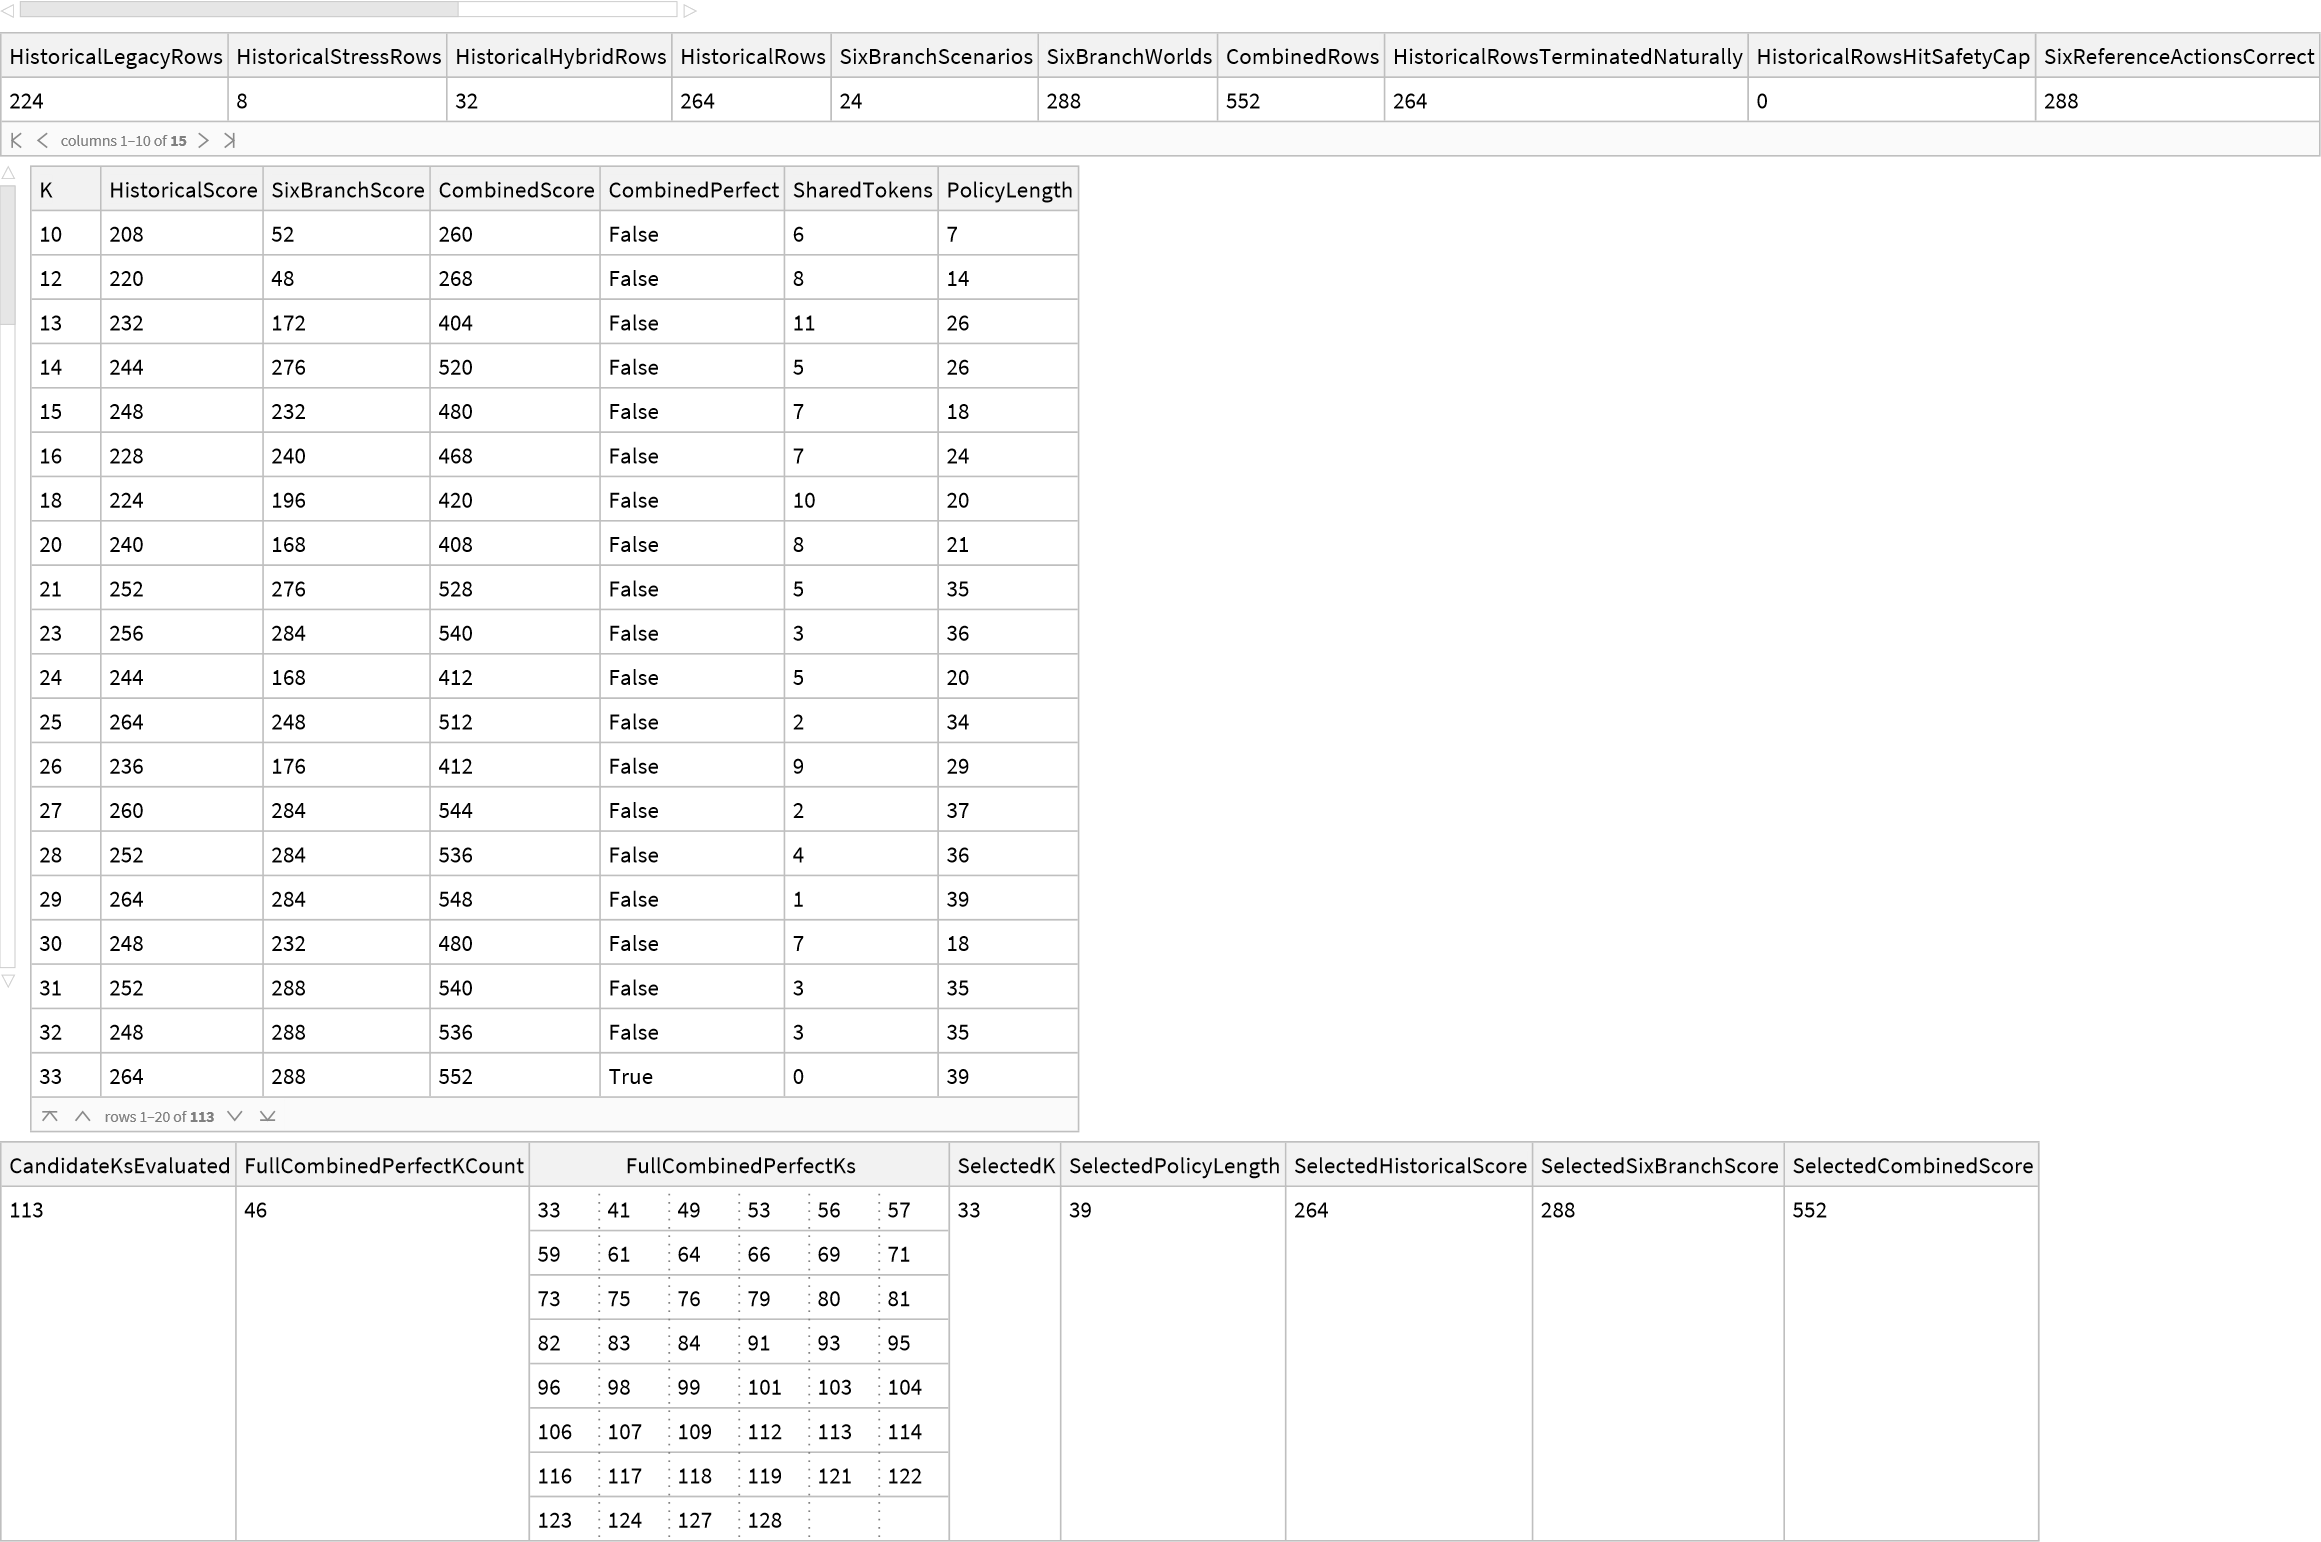

In [178]:
historicalSplit86D=BuildHistoricalRows86B[];
historicalRawRows86D=Map[
Join[#1,<|"Source"->"Historical264"|>]&,
Join[
historicalSplit86D["Legacy"],historicalSplit86D["Stress"],
historicalSplit86D["Hybrid"]
]
];

sixScenarios86D=Flatten[
Table[
PrepareDevelopmentScenario86B[topology,depth,patchedBranches],
{topology,blindTopologies86},{depth,blindDepths86},
{patchedBranches,blindPatchedBranchPairs86}
],2
];
sixRawRows86D=Flatten[Lookup[sixScenarios86D,"Worlds"],1];

kResults86D=EvaluateK86D/@localPerfectKs86D;
fullPerfectResults86D=Select[
kResults86D,TrueQ[#1["CombinedPerfect"]]&
];
selectedResult86D=If[
Length[fullPerfectResults86D]>0,
First@SortBy[fullPerfectResults86D,{#1["K"],#1["PolicyLength"]}&],
Missing["NoFullCombinedPerfectK"]
];

dataSummary86D=<|
"HistoricalLegacyRows"->Length[historicalSplit86D["Legacy"]],
"HistoricalStressRows"->Length[historicalSplit86D["Stress"]],
"HistoricalHybridRows"->Length[historicalSplit86D["Hybrid"]],
"HistoricalRows"->Length[historicalRawRows86D],
"SixBranchScenarios"->Length[sixScenarios86D],
"SixBranchWorlds"->Length[sixRawRows86D],
"CombinedRows"->Length[historicalRawRows86D]+Length[sixRawRows86D],
"HistoricalRowsTerminatedNaturally"->Count[
historicalRawRows86D,r_/;TrueQ[r["TerminatedNaturally"]]
],
"HistoricalRowsHitSafetyCap"->Count[
historicalRawRows86D,r_/;TrueQ[r["HitSafetyCap"]]
],
"SixReferenceActionsCorrect"->Count[
sixRawRows86D,r_/;SameQ[r["ReferenceAction"],r["Target"]]
],
"SixCanonicalExact"->Count[
sixRawRows86D,r_/;TrueQ[r["CanonicalCaseExactlyBase"]]
],
"SixProtectedNodesPreserved"->Count[
sixRawRows86D,r_/;TrueQ[r["ProtectedNodesPreserved"]]
],
"SixRowsTerminatedNaturally"->Count[
sixRawRows86D,r_/;TrueQ[r["TerminatedNaturally"]]
],
"SixRowsHitSafetyCap"->Count[
sixRawRows86D,r_/;TrueQ[r["HitSafetyCap"]]
],
"SixTotalTraceSeconds"->Total@Lookup[sixRawRows86D,"TraceSeconds"]
|>;

scanSummary86D=<|
"CandidateKsEvaluated"->Length[kResults86D],
"FullCombinedPerfectKCount"->Length[fullPerfectResults86D],
"FullCombinedPerfectKs"->Lookup[fullPerfectResults86D,"K"],
"SelectedK"->If[
AssociationQ[selectedResult86D],selectedResult86D["K"],selectedResult86D
],
"SelectedPolicyLength"->If[
AssociationQ[selectedResult86D],selectedResult86D["PolicyLength"],
Missing["NoSelection"]
],
"SelectedHistoricalScore"->If[
AssociationQ[selectedResult86D],selectedResult86D["HistoricalScore"],
Missing["NoSelection"]
],
"SelectedSixBranchScore"->If[
AssociationQ[selectedResult86D],selectedResult86D["SixBranchScore"],
Missing["NoSelection"]
],
"SelectedCombinedScore"->If[
AssociationQ[selectedResult86D],selectedResult86D["CombinedScore"],
Missing["NoSelection"]
]
|>;

Column[{
Dataset[{dataSummary86D}],
Dataset[Map[KeyDrop[#1,"Policy"]&,kResults86D]],
Dataset[{scanSummary86D}]
}]


Dataset[{<|Stage -> S86D, Name -> FullCombinedKFeasibilityScan, AuditOnly -> True, 
 
>     ScanValidityPassed -> True, CandidateKsEvaluated -> 113, 
 
>     FullCombinedPerfectKCount -> 46, 
 
>     FullCombinedPerfectKs -> 
 
>      {33, 41, 49, 53, 56, 57, 59, 61, 64, 66, 69, 71, 73, 75, 76, 79, 80, 81, 82, 83, 
 
>       84, 91, 93, 95, 96, 98, 99, 101, 103, 104, 106, 107, 109, 112, 113, 114, 116, 
 
>       117, 118, 119, 121, 122, 123, 124, 127, 128}, SelectedK -> 33, 
 
>     SelectedPolicyLength -> 39, SelectedHistoricalScore -> 264, 
 
>     SelectedSixBranchScore -> 288, SelectedCombinedScore -> 552, 
 
>     OriginalFrozenModelChanged -> False, FrozenCandidateChanged -> False, 
 
>     CoreChanged -> False, CanonicalizerChanged -> False, InterventionChanged -> False, 
 
>     DeduplicationMechanismChanged -> False, PolicyAppliedToFrozenCandidate -> False, 
 
>     NewCandidateSelected -> False, CandidateExported -> False, 
 
>     S86DIsBlindTest -> False, S87DataUsed -> False, 
 
>     Outcome -> FULL_COMBINED_PERFECT_K_EXISTS, 
 
>     SuggestedNextStage -> S86E_FREEZE_SELECTED_K_AND_REVEALED_REGRESSION|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 25], 
 
>    1], <||>]
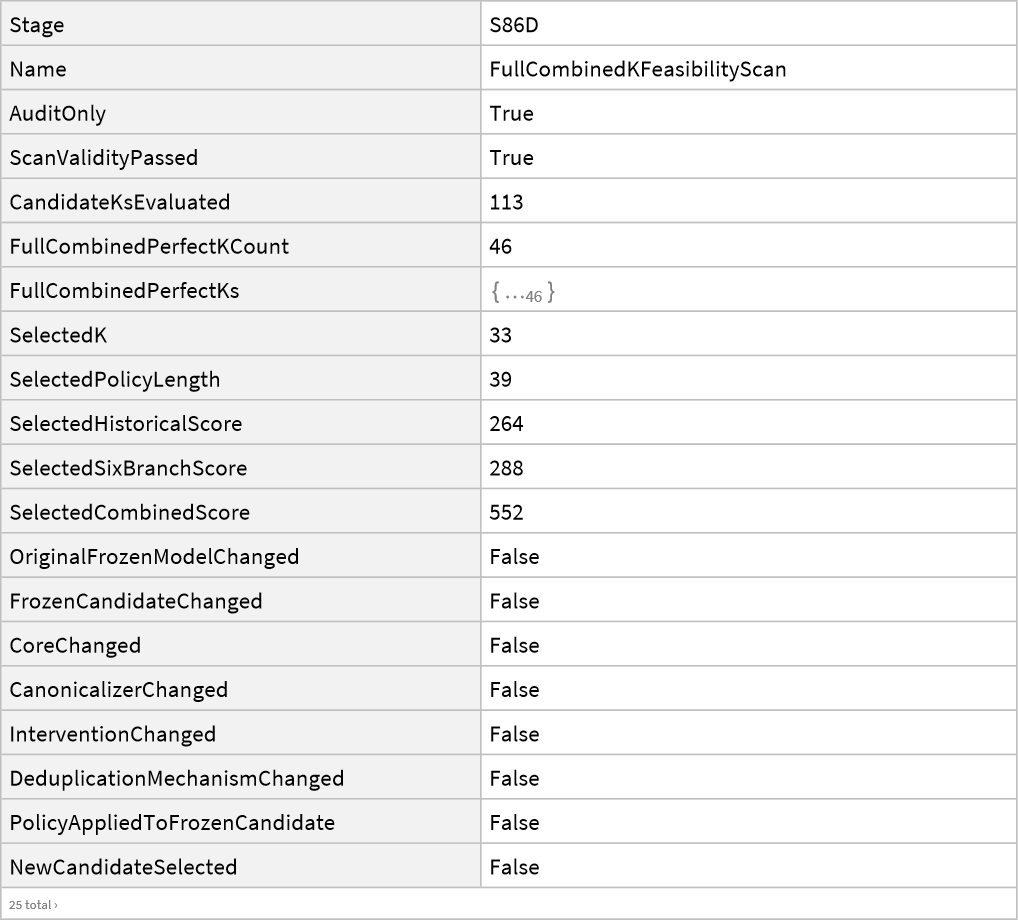

In [188]:
modelHashAfter86D=Hash[Normal[frozen75D],"SHA256","HexString"];
candidateHashAfter86D=Hash[Normal[frozenCandidate83B],"SHA256","HexString"];
coreHashAfter86D=Hash[CoreDefinitionBundle86[],"SHA256","HexString"];
canonicalizerHashAfter86D=canonicalizerImplementationHash79B;
interventionHashAfter86D=interventionImplementationHash82;
definitionHashAfter86D=Hash[S86DDefinitionBundle[],"SHA256","HexString"];
protocolHashAfter86D=Hash[Normal[protocol86D],"SHA256","HexString"];

scanValidityPassed86D=And[
TrueQ[preflightPassed86D],
SameQ[protocolHash86D,protocolHashAfter86D],
SameQ[modelHashBefore86D,modelHashAfter86D],
SameQ[candidateHashBefore86D,candidateHashAfter86D],
SameQ[candidateHashAfter86D,expectedBaseCandidateHash86D],
SameQ[coreHashBefore86D,coreHashAfter86D],
SameQ[canonicalizerHashBefore86D,canonicalizerHashAfter86D],
SameQ[interventionHashBefore86D,interventionHashAfter86D],
SameQ[definitionHashBefore86D,definitionHashAfter86D],
SameQ[dataSummary86D["HistoricalLegacyRows"],224],
SameQ[dataSummary86D["HistoricalStressRows"],8],
SameQ[dataSummary86D["HistoricalHybridRows"],32],
SameQ[dataSummary86D["HistoricalRows"],264],
SameQ[dataSummary86D["SixBranchScenarios"],24],
SameQ[dataSummary86D["SixBranchWorlds"],288],
SameQ[dataSummary86D["CombinedRows"],552],
SameQ[dataSummary86D["HistoricalRowsTerminatedNaturally"],264],
SameQ[dataSummary86D["HistoricalRowsHitSafetyCap"],0],
SameQ[dataSummary86D["SixReferenceActionsCorrect"],288],
SameQ[dataSummary86D["SixCanonicalExact"],288],
SameQ[dataSummary86D["SixProtectedNodesPreserved"],288],
SameQ[dataSummary86D["SixRowsTerminatedNaturally"],288],
SameQ[dataSummary86D["SixRowsHitSafetyCap"],0],
SameQ[Length[kResults86D],113]
];

cert86D=<|
"Stage"->"S86D",
"Name"->"FullCombinedKFeasibilityScan",
"AuditOnly"->True,
"ScanValidityPassed"->scanValidityPassed86D,
"CandidateKsEvaluated"->Length[kResults86D],
"FullCombinedPerfectKCount"->Length[fullPerfectResults86D],
"FullCombinedPerfectKs"->Lookup[fullPerfectResults86D,"K"],
"SelectedK"->scanSummary86D["SelectedK"],
"SelectedPolicyLength"->scanSummary86D["SelectedPolicyLength"],
"SelectedHistoricalScore"->scanSummary86D["SelectedHistoricalScore"],
"SelectedSixBranchScore"->scanSummary86D["SelectedSixBranchScore"],
"SelectedCombinedScore"->scanSummary86D["SelectedCombinedScore"],
"OriginalFrozenModelChanged"->!SameQ[modelHashBefore86D,modelHashAfter86D],
"FrozenCandidateChanged"->!SameQ[candidateHashBefore86D,candidateHashAfter86D],
"CoreChanged"->!SameQ[coreHashBefore86D,coreHashAfter86D],
"CanonicalizerChanged"->!SameQ[
canonicalizerHashBefore86D,canonicalizerHashAfter86D
],
"InterventionChanged"->!SameQ[
interventionHashBefore86D,interventionHashAfter86D
],
"DeduplicationMechanismChanged"->False,
"PolicyAppliedToFrozenCandidate"->False,
"NewCandidateSelected"->False,
"CandidateExported"->False,
"S86DIsBlindTest"->False,
"S87DataUsed"->False,
"Outcome"->Which[
!TrueQ[scanValidityPassed86D],"INVALID_S86D_SCAN",
Length[fullPerfectResults86D]>0,"FULL_COMBINED_PERFECT_K_EXISTS",
True,"NO_K10_THROUGH128_SOLVES_FULL_COMBINED_DATA"
],
"SuggestedNextStage"->If[
TrueQ[scanValidityPassed86D]&&Length[fullPerfectResults86D]>0,
"S86E_FREEZE_SELECTED_K_AND_REVEALED_REGRESSION",
"S86E_OUTER_STRUCTURAL_CONTEXT_AUDIT"
]
|>;

Dataset[{cert86D}]
